In [8]:
import numpy as np
import pandas as pd

# Data Injection

In [9]:
df = pd.read_csv("attrition_dataset.csv")

# Data Inspection and basic data improving

In [10]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


* Employee ID column should be removed

In [11]:
df.shape

(59598, 24)

* 59.5+ rows
* 24 columns/features

df.columns

In [13]:
df.duplicated().sum()

np.int64(0)

* No duplicate rows

In [14]:
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

* No null / empty values

In [15]:
df = df.drop(columns=["Employee ID"])

In [16]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


* No logical mistakes in numerical data

In [17]:
df.dtypes

Age                         int64
Gender                        str
Years at Company            int64
Job Role                      str
Monthly Income              int64
Work-Life Balance             str
Job Satisfaction              str
Performance Rating            str
Number of Promotions        int64
Overtime                      str
Distance from Home          int64
Education Level               str
Marital Status                str
Number of Dependents        int64
Job Level                     str
Company Size                  str
Company Tenure              int64
Remote Work                   str
Leadership Opportunities      str
Innovation Opportunities      str
Company Reputation            str
Employee Recognition          str
Attrition                     str
dtype: object

* All column has correct datatype

*Numeric Columns*

In [18]:
df.select_dtypes(include=["int"]).columns

Index(['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions',
       'Distance from Home', 'Number of Dependents', 'Company Tenure'],
      dtype='str')

*Categorical / Object Columns*

In [19]:
df.select_dtypes(include=["object"]).drop(columns=["Attrition"]).columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_23172\3041183662.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).drop(columns=["Attrition"]).columns


Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition'],
      dtype='str')

In [20]:
num_cols = df.select_dtypes(include=["int"]).columns
cat_cols = df.select_dtypes(include=["object"]).drop(columns=["Attrition"]).columns
tar_col = df["Attrition"]

C:\Users\Admin\AppData\Local\Temp\ipykernel_23172\842798154.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).drop(columns=["Attrition"]).columns


# Exploratory Data Analysis

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


**Univariate Analysis**

*Numeric Columns*

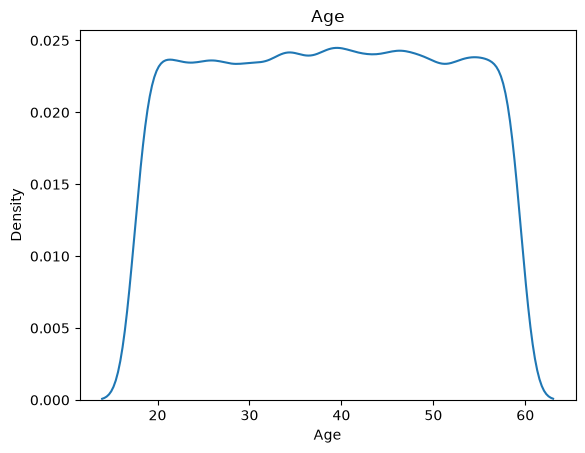

-0.0070468926610102395


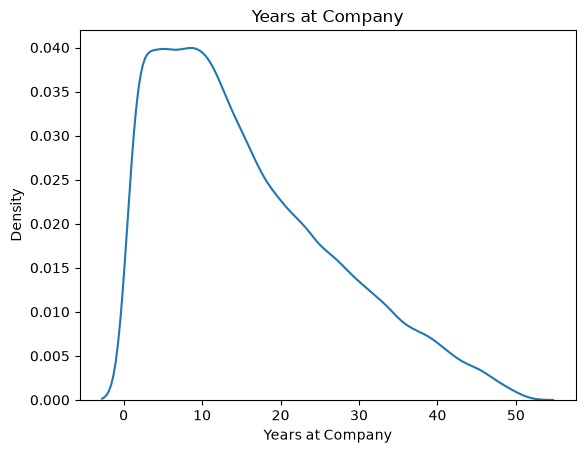

0.7881440617230528


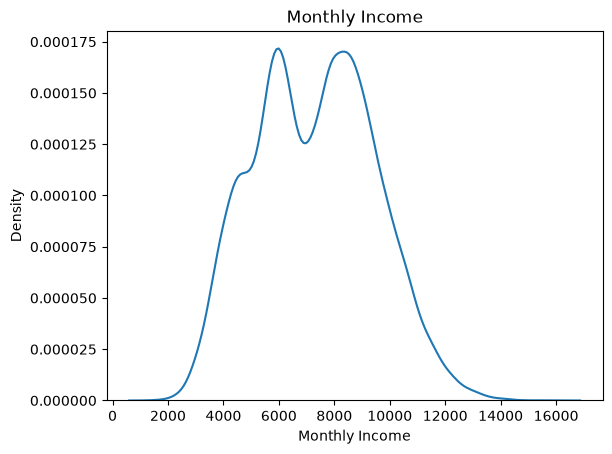

0.11509059762342143


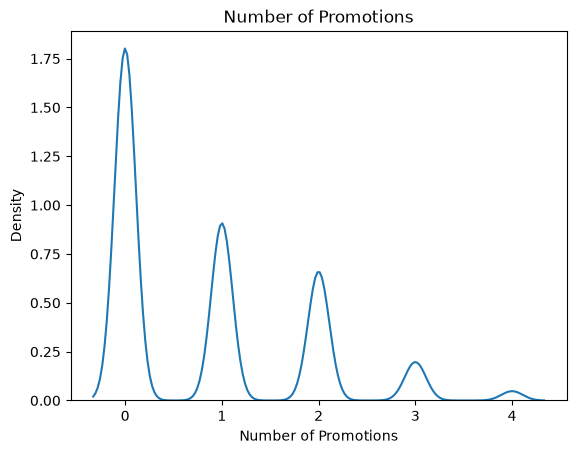

0.9934263573883052


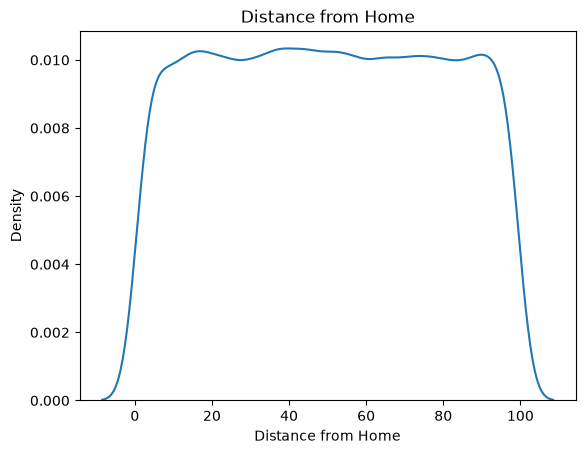

0.002878652846663206


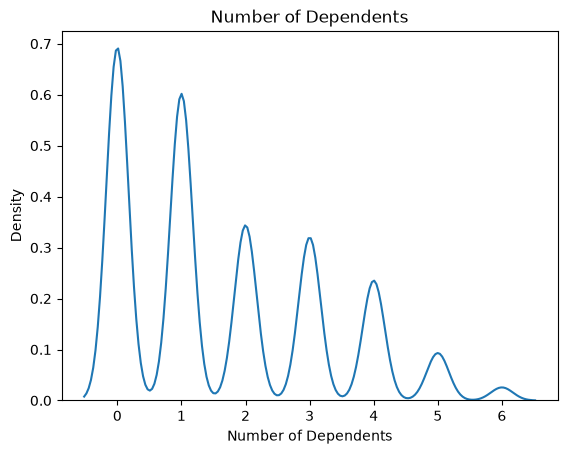

0.715559102399293


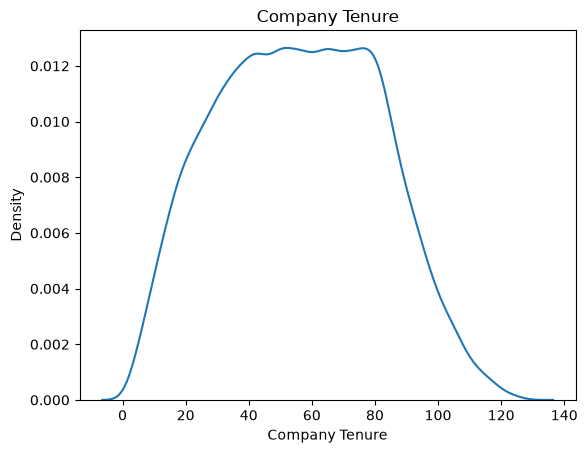

0.06668835341281293


In [22]:
right_skewed_cols = []
left_skewed_cols = []
nrml_skewed_cols = []
for col in num_cols:
    sns.kdeplot(x=col,data=df)
    plt.title(col)
    plt.show()
    print(df[col].skew())
    if df[col].skew()>=0.6:
        right_skewed_cols.append(col)
    elif df[col].skew()<=-0.6:
        left_skewed_cols.append(col)
    else:
        nrml_skewed_cols.append(col)

In [23]:
print(f"Right skewed cols: {right_skewed_cols}")
print(f"Left skewed cols: {left_skewed_cols}")
print(f"Nrml skewed cols: {nrml_skewed_cols}")

Right skewed cols: ['Years at Company', 'Number of Promotions', 'Number of Dependents']
Left skewed cols: []
Nrml skewed cols: ['Age', 'Monthly Income', 'Distance from Home', 'Company Tenure']


* The numeric cols are not >= skewed to -0.6
* 3 cols are skewed right
* 4 cols are almost nrml skewed

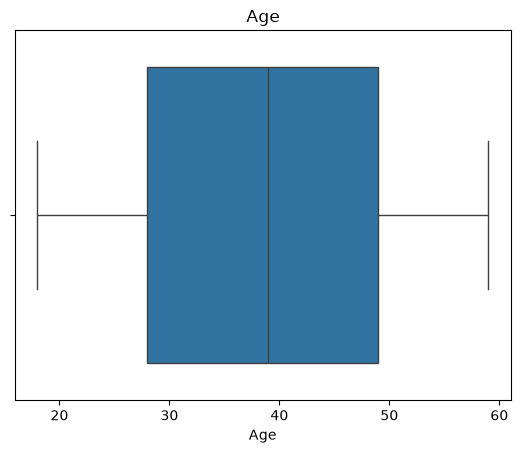

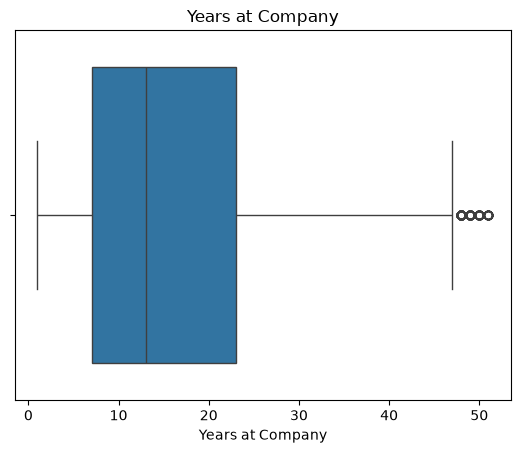

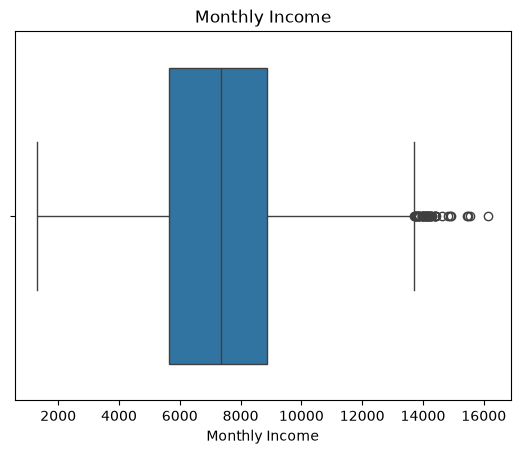

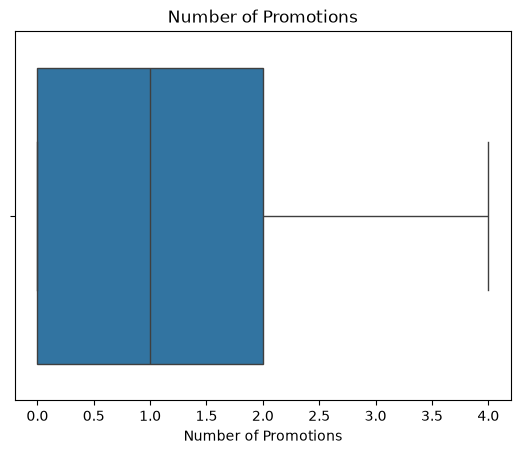

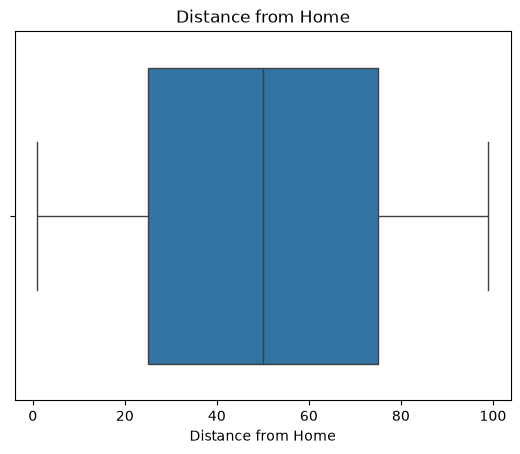

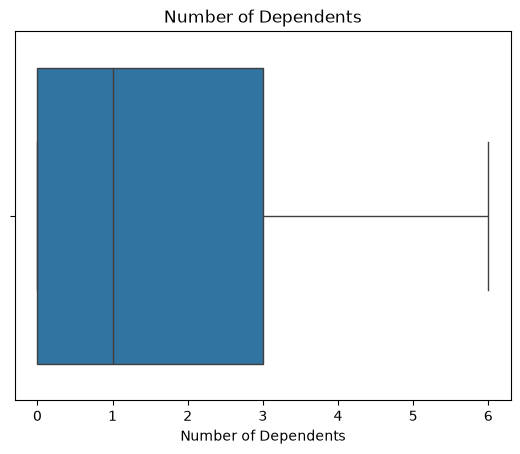

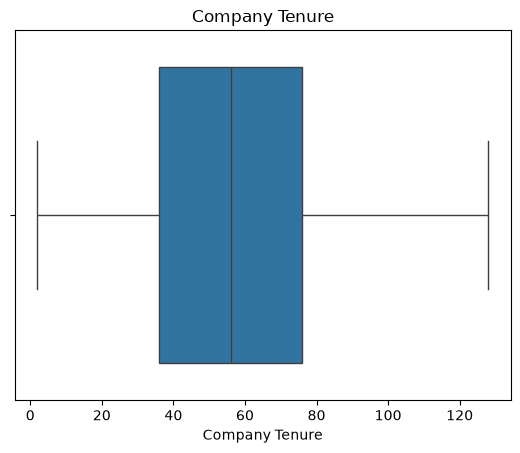

In [24]:
for col in num_cols:
    sns.boxplot(x=col,data=df)
    plt.title(col)
    plt.show()

* Less outliers present in "Years at Company" col
* Many outliers present in "Monthly Income" col

*Categorical Columns*

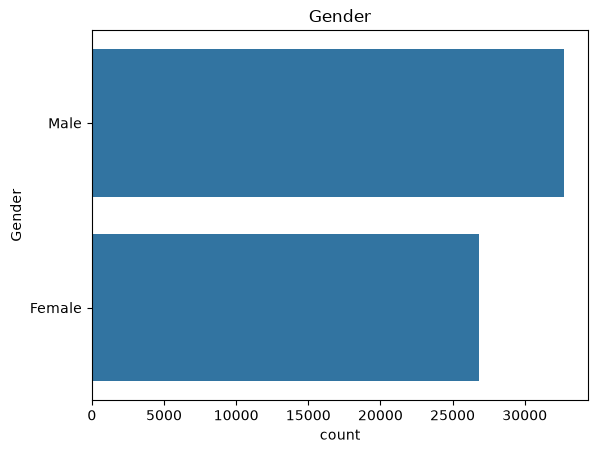

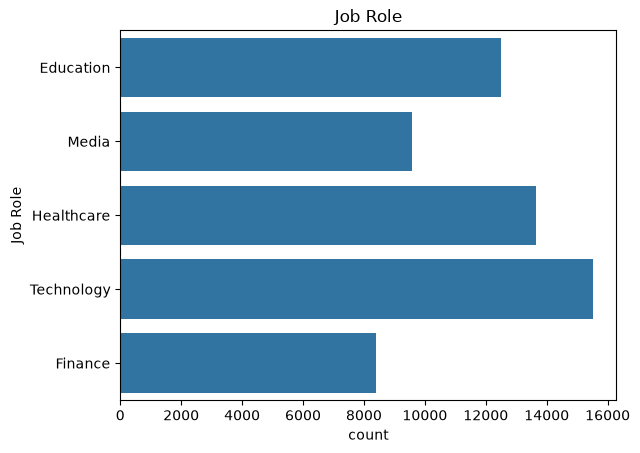

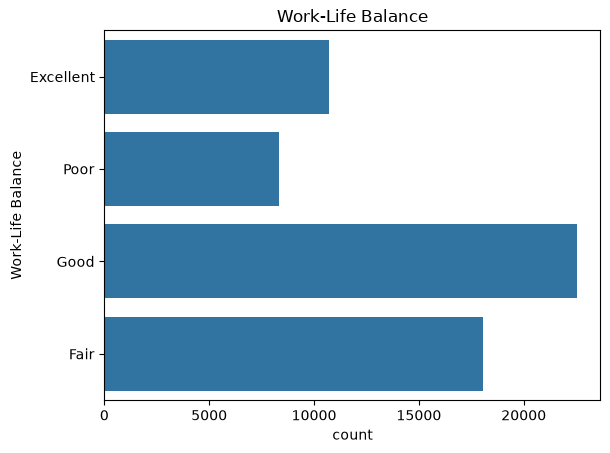

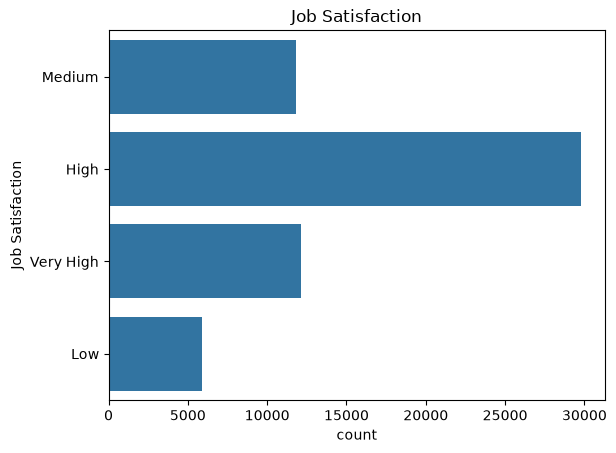

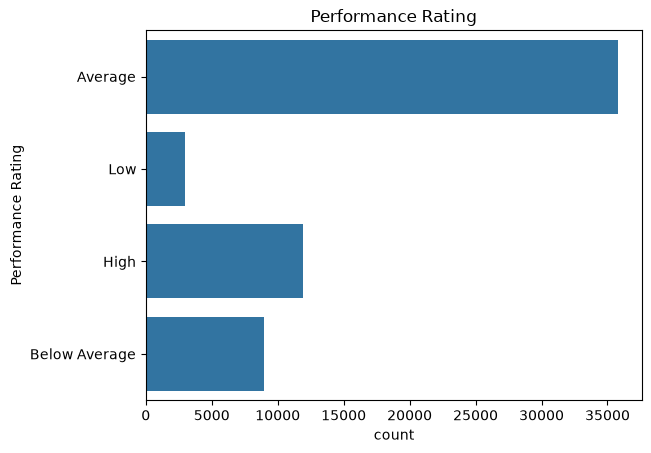

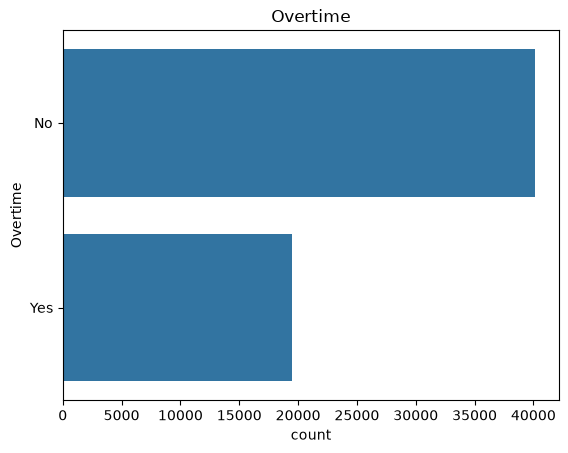

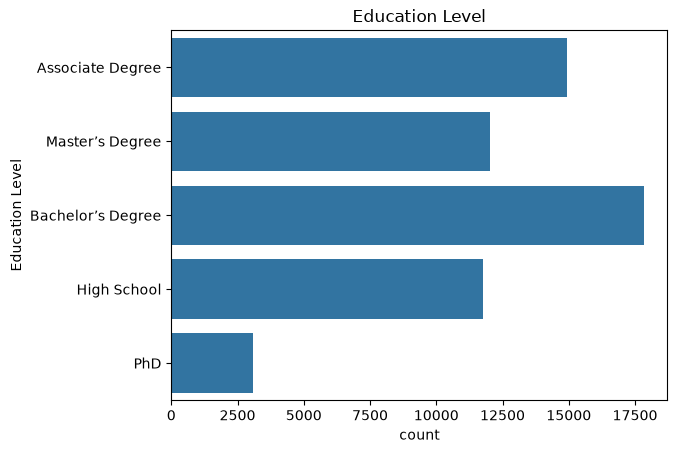

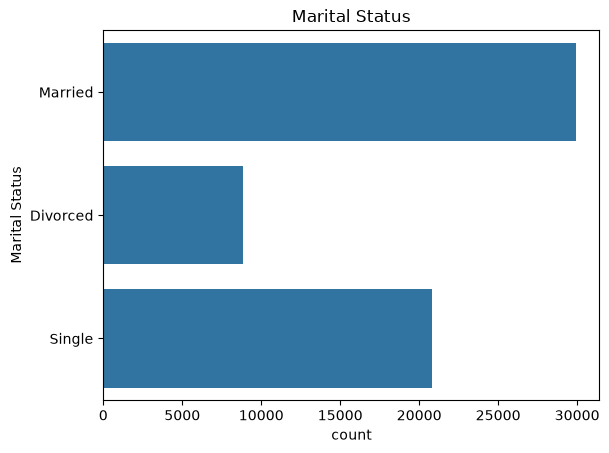

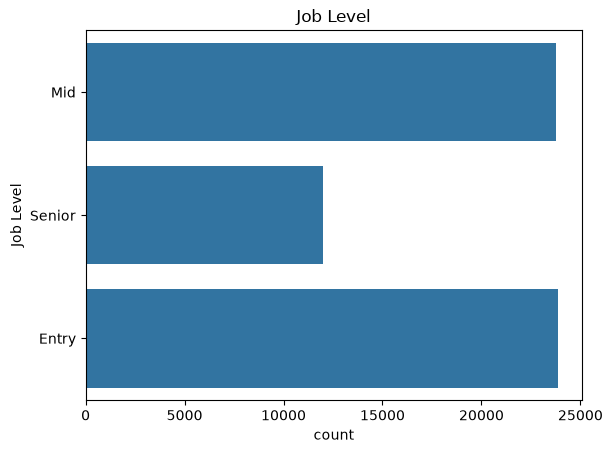

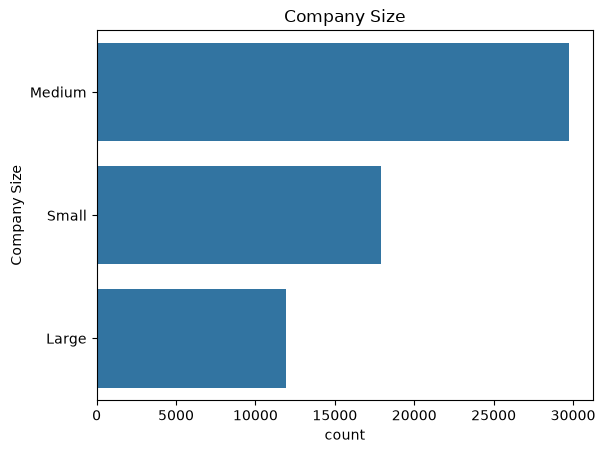

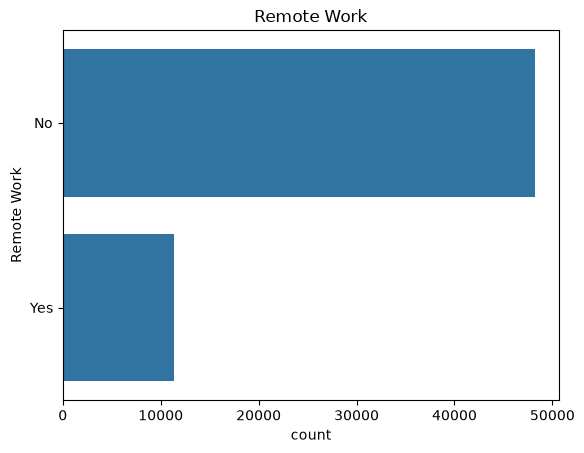

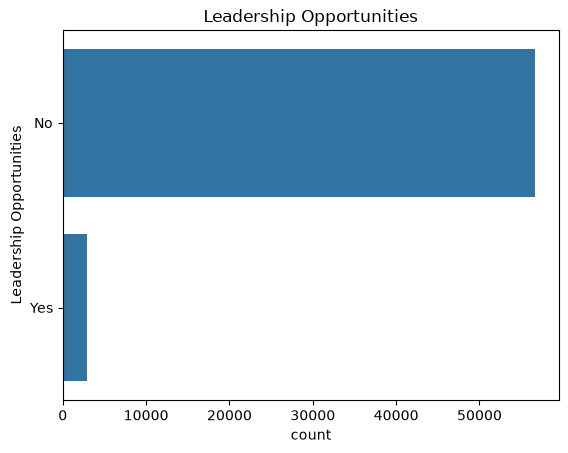

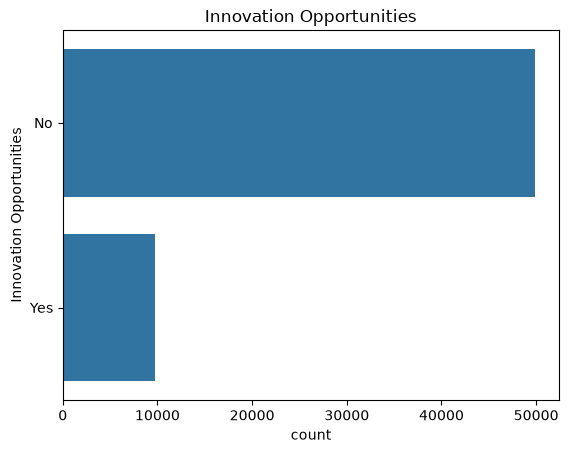

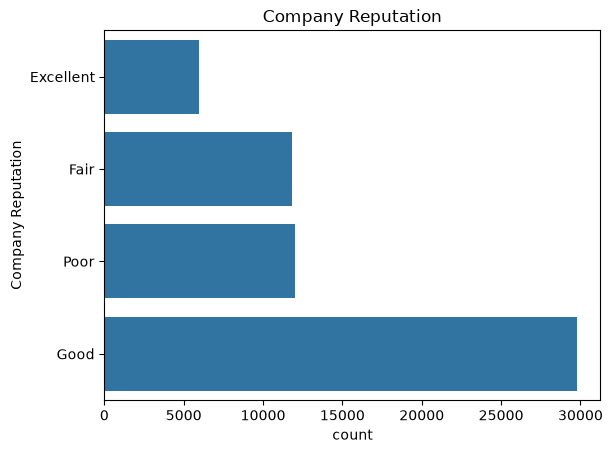

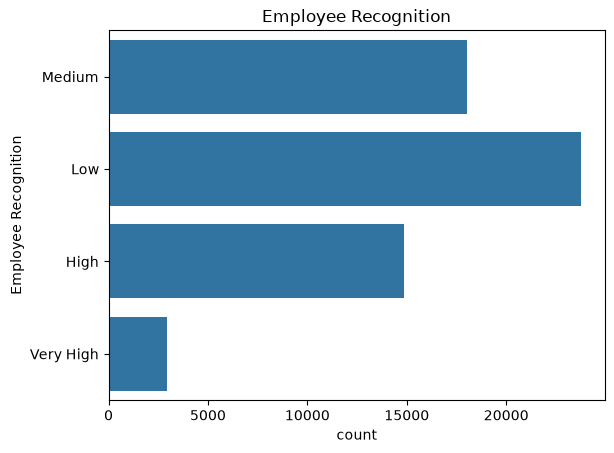

In [25]:
for col in cat_cols:
    sns.countplot(y=col,data=df)
    plt.title(col)
    plt.show()

*Target Column*

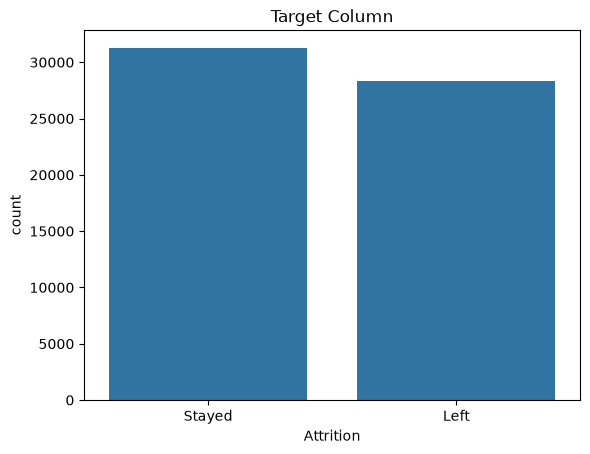

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64



Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


In [26]:
sns.countplot(x=tar_col,data=df)
plt.title("Target Column")
plt.show()
print(tar_col.value_counts())
print("\n\n")
print(tar_col.value_counts(normalize=True)*100)

* ~5% data is imbalance only
* So,no need of handling imbalance

**Bivariate Analysis**

*Num cols VS Target col*

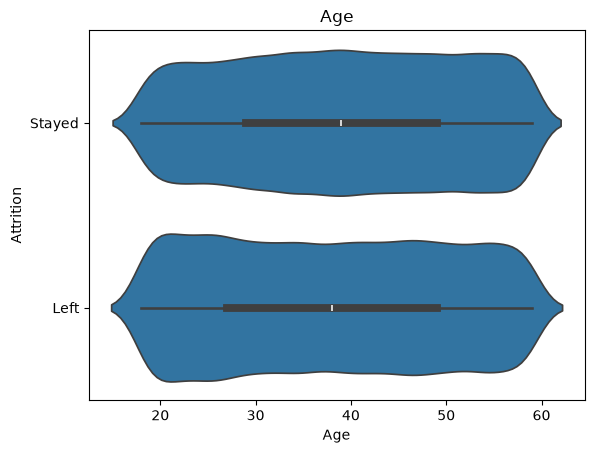

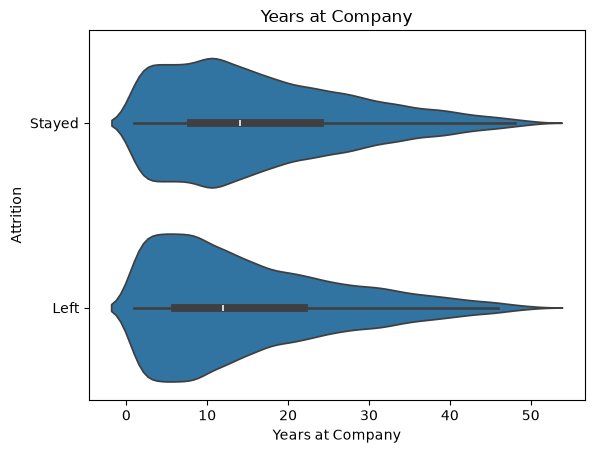

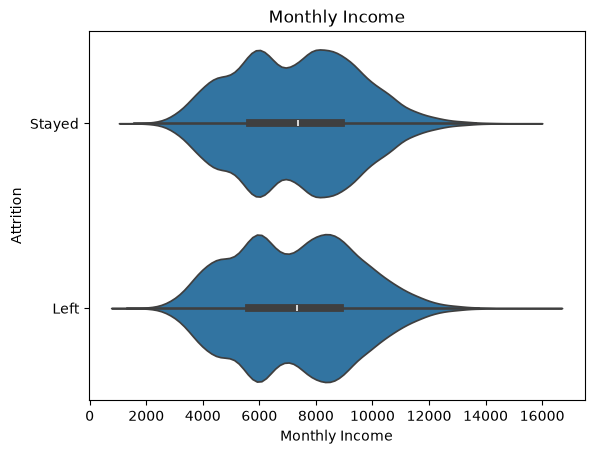

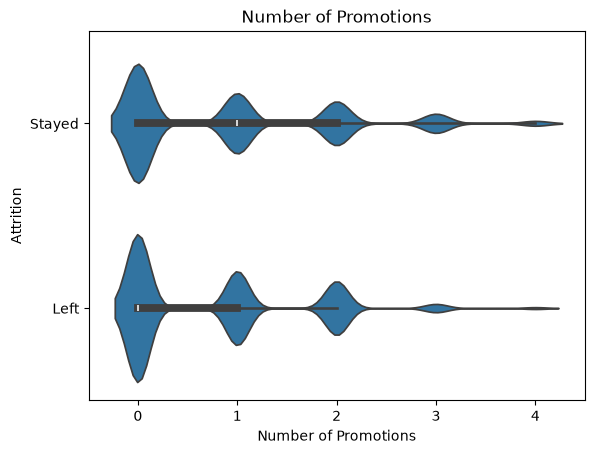

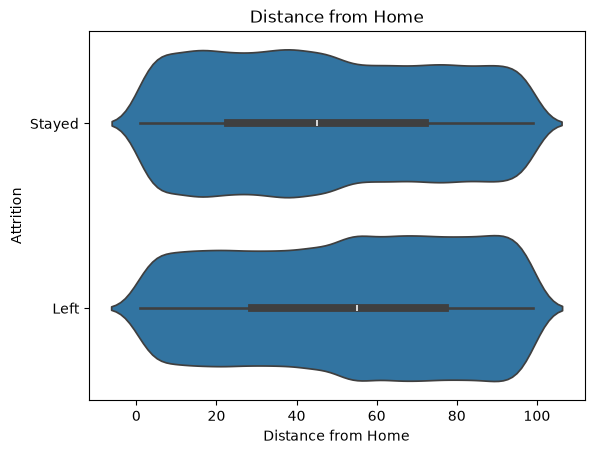

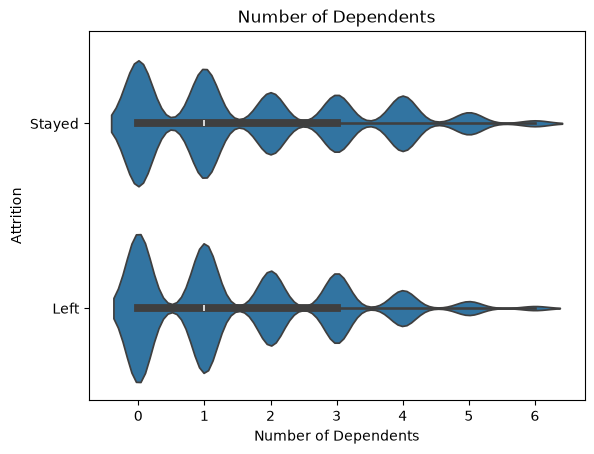

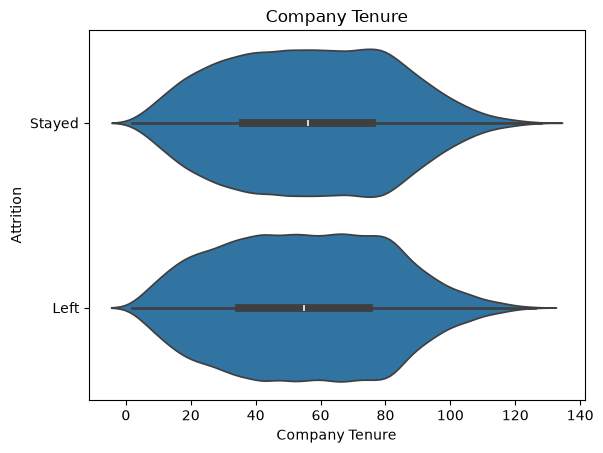

In [27]:
for col in num_cols:
    sns.violinplot(x=col,y=tar_col,data=df)
    plt.title(col)
    plt.show()

*Cat cols VS Target col*

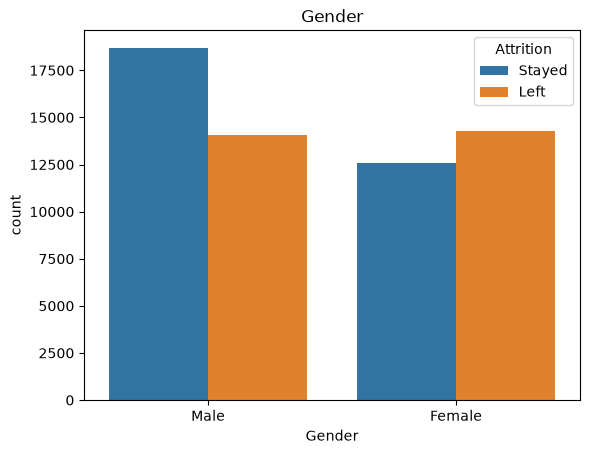

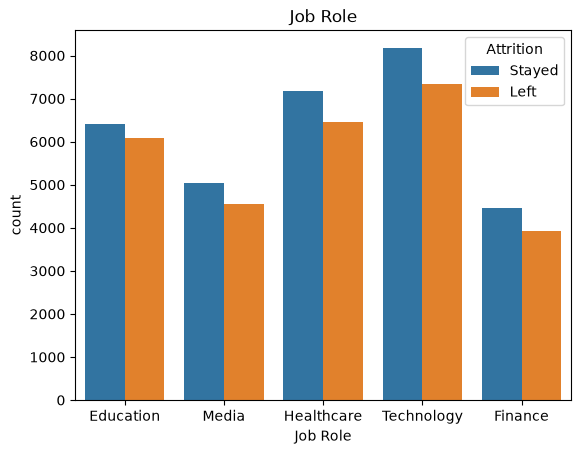

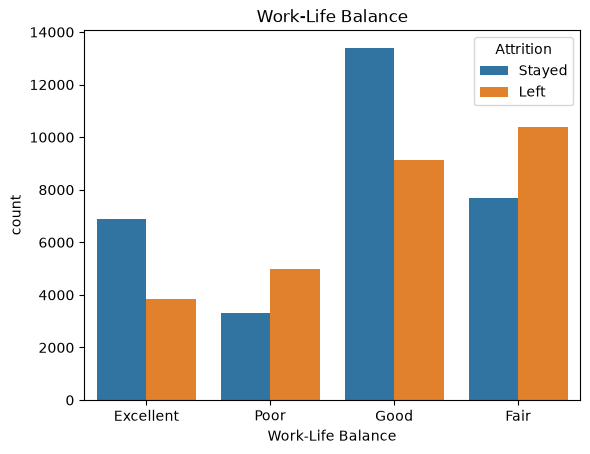

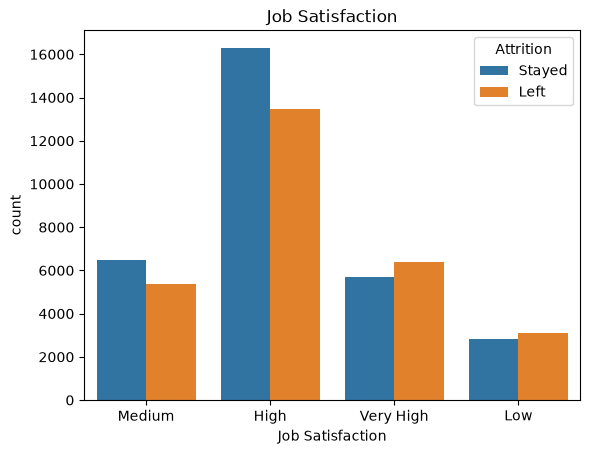

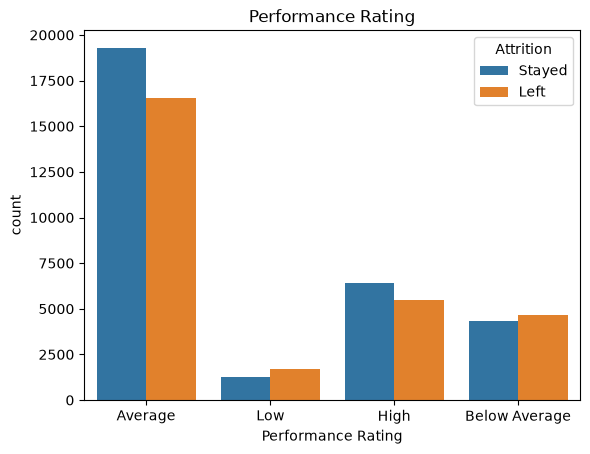

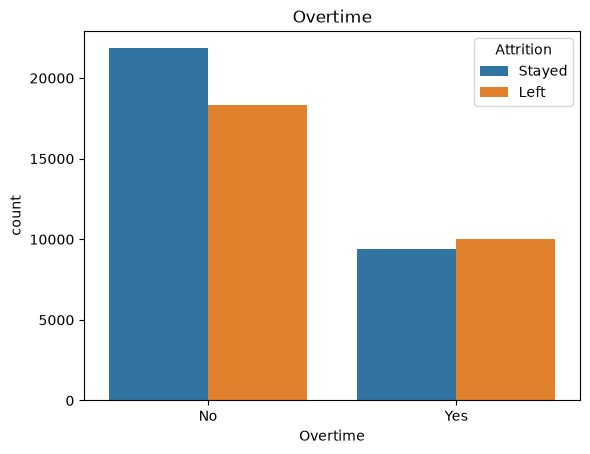

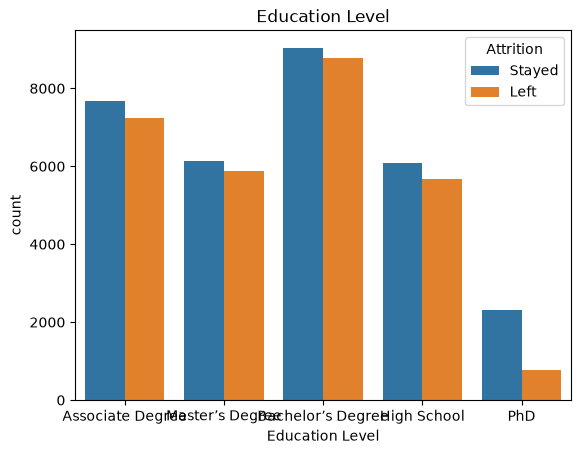

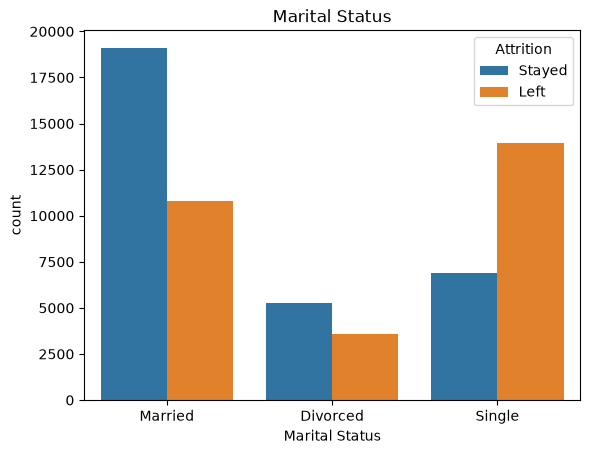

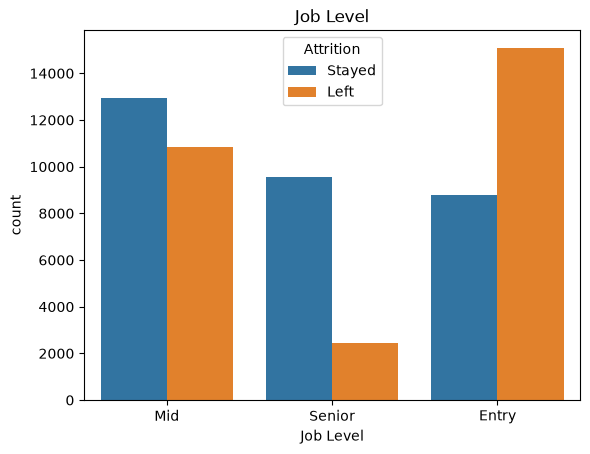

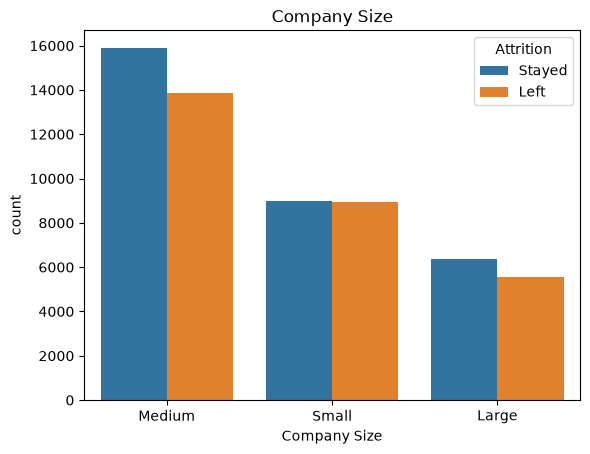

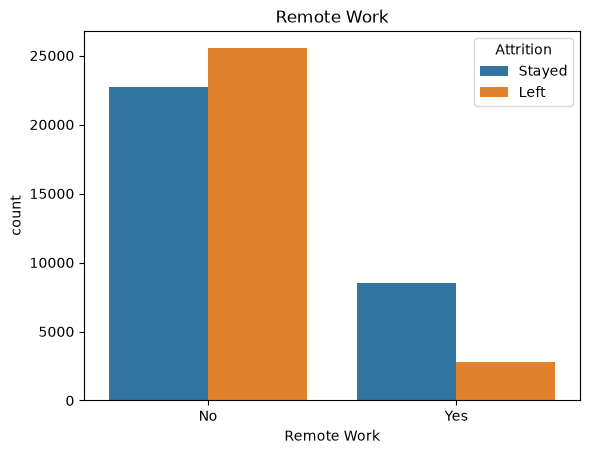

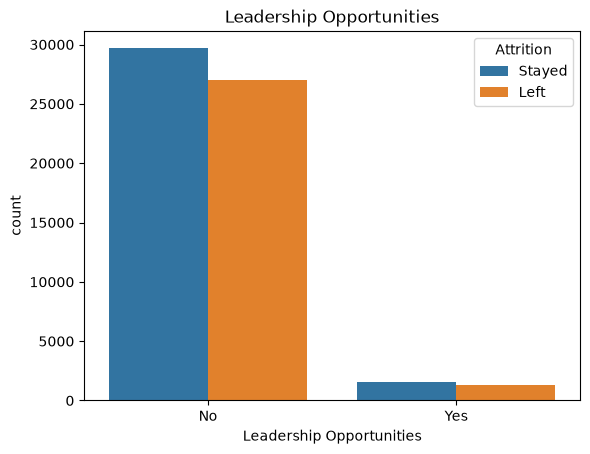

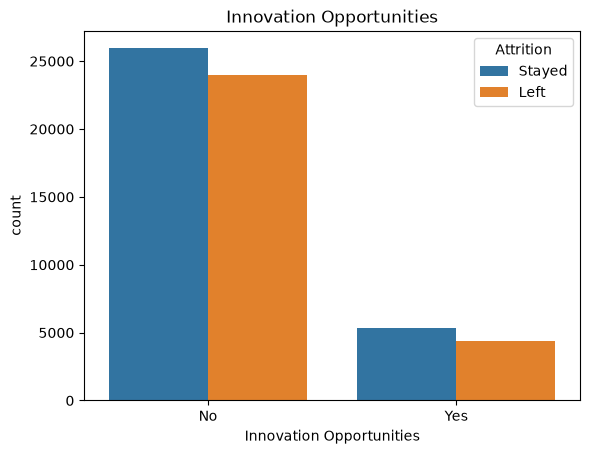

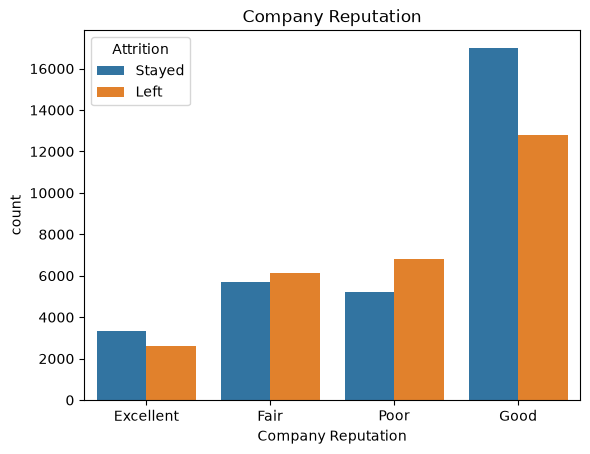

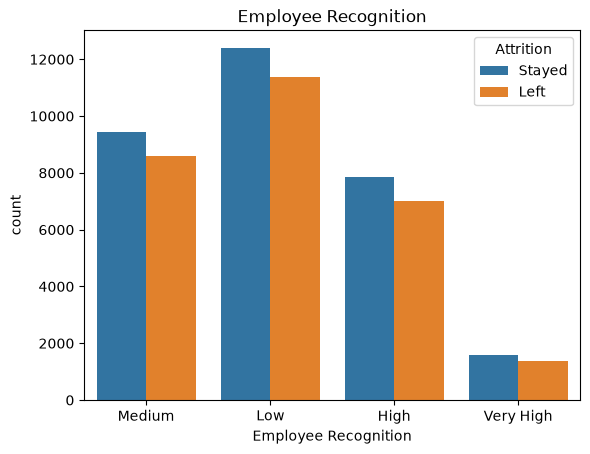

In [28]:
for col in cat_cols:
    sns.countplot(x=col,hue=tar_col,data=df)
    plt.title(col)
    plt.show()

**Multivariate Analysis**

<Axes: >

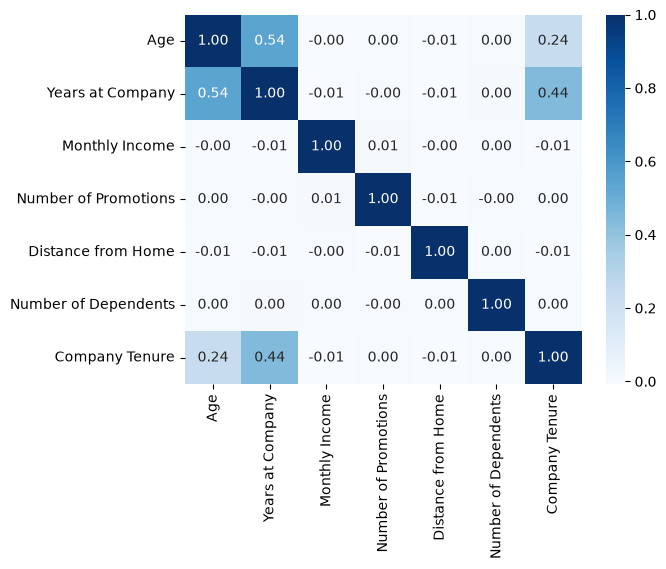

In [29]:
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f",cmap="Blues")

* No multicollinearity

# Handling Outliers

In [30]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    df[col] = df[col].clip(lower,upper)

# Feature Engg

In [61]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_recall_curve,f1_score,precision_score,recall_score
import optuna

In [32]:
x = df.drop(columns=["Attrition"])
y = df["Attrition"]

# Splitting data

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=True)

# Encoding Target values

In [34]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [35]:
le.classes_

array(['Left', 'Stayed'], dtype=object)

# Pipelines for each type of data

In [36]:
right_skew_pipeline = Pipeline(steps=[
    ("right_skew_imputer",SimpleImputer(strategy="mean")),
    ("right_skew_transformer",FunctionTransformer(np.log1p,feature_names_out='one-to-one')),
    ("right_skew_scaling",StandardScaler())
])

In [37]:
nrml_skew_pipeline = Pipeline(steps=[
    ("nrml_skew_imputer",SimpleImputer(strategy="mean")),
    ("nrml_skew_scaling",StandardScaler())
])

In [38]:
cat_pipeline = Pipeline(steps=[
    ("OHEncoder",OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessing ColumnTransformer

In [39]:
preprocessing = ColumnTransformer(transformers=[
    ("right_skew_pipeline",right_skew_pipeline,right_skewed_cols),
    ("nrml_skew_pipeline",nrml_skew_pipeline,nrml_skewed_cols),
    ("cat_pipeline",cat_pipeline,cat_cols)
],remainder = "passthrough")

# Finding best model and best params (Optuna)

In [40]:
def objective(trial):
    model_name = trial.suggest_categorical("model", ["lr", "dt", "rf", "xgb"])

    if model_name == "lr":
        model = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 10, log=True),
        solver=trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
        max_iter=1000
    )

    elif model_name == "dt":
        model = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"])
    )

    elif model_name == "rf":
        model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        n_jobs=-1
    )

    elif model_name == "xgb":
        model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 5),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 5),
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1,
        verbosity=0
    )
    pipeline = Pipeline(steps=[
        ("preprocessing",preprocessing),
        ("model",model)
    ])
    pipeline.fit(x_train,y_train)
    pipeline_pred = pipeline.predict(x_test)
    score = f1_score(y_test,pipeline_pred)
    return score

In [41]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=100)

[I 2026-06-21 13:08:10,557] A new study created in memory with name: no-name-031f3390-75f3-4cb3-9104-d3e3467508d5
[I 2026-06-21 13:08:11,148] Trial 0 finished with value: 0.7633491311216429 and parameters: {'model': 'lr', 'C': 0.003918688047487157, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7633491311216429.
[I 2026-06-21 13:08:12,464] Trial 1 finished with value: 0.6987652989701839 and parameters: {'model': 'dt', 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.7633491311216429.
[I 2026-06-21 13:08:17,077] Trial 2 finished with value: 0.7554520431928858 and parameters: {'model': 'xgb', 'n_estimators': 397, 'learning_rate': 0.25136271414193656, 'max_depth': 6, 'subsample': 0.5034350327628829, 'colsample_bytree': 0.6563342164362537, 'gamma': 2.4585894272981133, 'reg_alpha': 0.8936996455400376, 'reg_lambda': 2.2890136387562294}. Best is trial 0 with value: 0.7633491311216429.
[I 2026-06-21 13:08:18,142] Trial 3 fi

In [42]:
params = study.best_params
params

{'model': 'xgb',
 'n_estimators': 434,
 'learning_rate': 0.035590918551888034,
 'max_depth': 3,
 'subsample': 0.5726257326910803,
 'colsample_bytree': 0.7655229006373381,
 'gamma': 1.8920701920209764,
 'reg_alpha': 4.616295956624399,
 'reg_lambda': 0.10911582663620534}

In [43]:
model_name = params["model"]

if model_name == "lr":
    final_model = LogisticRegression(
        C=params["C"],
        solver=params["solver"],
        max_iter=1000
    )

elif model_name == "dt":
    final_model = DecisionTreeClassifier(
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        criterion=params["criterion"]
    )

elif model_name == "rf":
    final_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=-1
    )

elif model_name == "xgb":
    final_model = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1,
        verbosity=0
    )


# Final Pipeline (preprocessing + best model with best params)

In [44]:
final_pipeline = Pipeline(steps=[
    ("preprocessing",preprocessing),
    ("final_model",final_model)
])

# Training full pipeline on training data

In [45]:
final_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('final_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','Gender','Years at Company',...,'Innovation Opportunities', 'Company Reputation','Employee Recognition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('right_skew_pipeline', ...), ('nrml_skew_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns a

# Prediction on test data

In [46]:
y_train_pred = final_pipeline.predict(x_train)
y_test_pred = final_pipeline.predict(x_test)

# Model Evaluation

**Accuracy**

In [47]:
train_acc = accuracy_score(y_train,y_train_pred)
print(f"Train acc: {train_acc}")
test_acc = accuracy_score(y_test,y_test_pred)
print(f"Test acc: {test_acc}")

Train acc: 0.7624047173881777
Test acc: 0.7602908277404922


In [48]:
train_cr = classification_report(y_train,y_train_pred,target_names=le.classes_)
print(f"Train cr: \n{train_cr}")
test_cr = classification_report(y_test,y_test_pred,target_names=le.classes_)
print(f"\n\nTest cr: \n{test_cr}")

Train cr: 
              precision    recall  f1-score   support

        Left       0.75      0.75      0.75     19822
      Stayed       0.77      0.78      0.77     21896

    accuracy                           0.76     41718
   macro avg       0.76      0.76      0.76     41718
weighted avg       0.76      0.76      0.76     41718



Test cr: 
              precision    recall  f1-score   support

        Left       0.75      0.74      0.75      8516
      Stayed       0.77      0.78      0.77      9364

    accuracy                           0.76     17880
   macro avg       0.76      0.76      0.76     17880
weighted avg       0.76      0.76      0.76     17880



Train cm


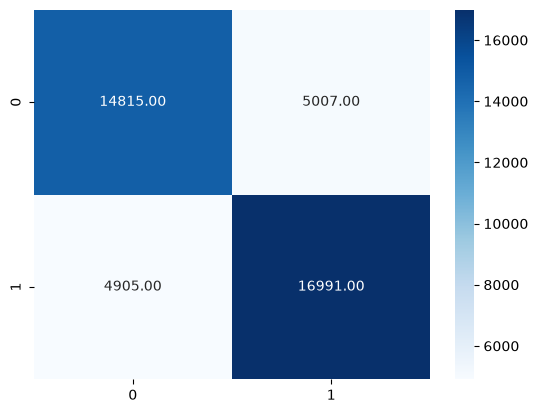



Test cm


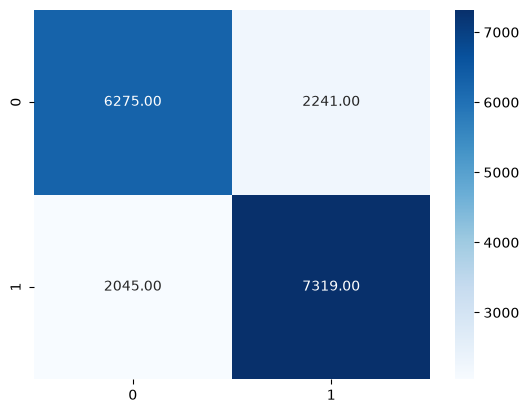

In [49]:
train_cm = confusion_matrix(y_train,y_train_pred)
print(f"Train cm")
sns.heatmap(train_cm,annot=True,fmt=".2f",cmap="Blues")
plt.show()
test_cm = confusion_matrix(y_test,y_test_pred,)
print(f"\n\nTest cm")
sns.heatmap(test_cm,annot=True,fmt=".2f",cmap="Blues")
plt.show()

# Saving final_pipeline as .pkl file

In [50]:
import joblib
joblib.dump(final_pipeline,"final_pipeline.pkl")

['final_pipeline.pkl']

# Model Explainability (Shap)

In [51]:
import shap

In [52]:
shap_preprocessor = final_pipeline.named_steps["preprocessing"]
shap_model = final_pipeline.named_steps["final_model"]

In [53]:
feature_names = []
for col in shap_preprocessor.get_feature_names_out():
    feature_names.append(col.split("__")[-1])

In [54]:
x_test_t = pd.DataFrame(
    shap_preprocessor.transform(x_test),
    columns=feature_names
)

In [55]:
explainer = shap.Explainer(shap_model)

In [56]:
shap_values = explainer(x_test_t)

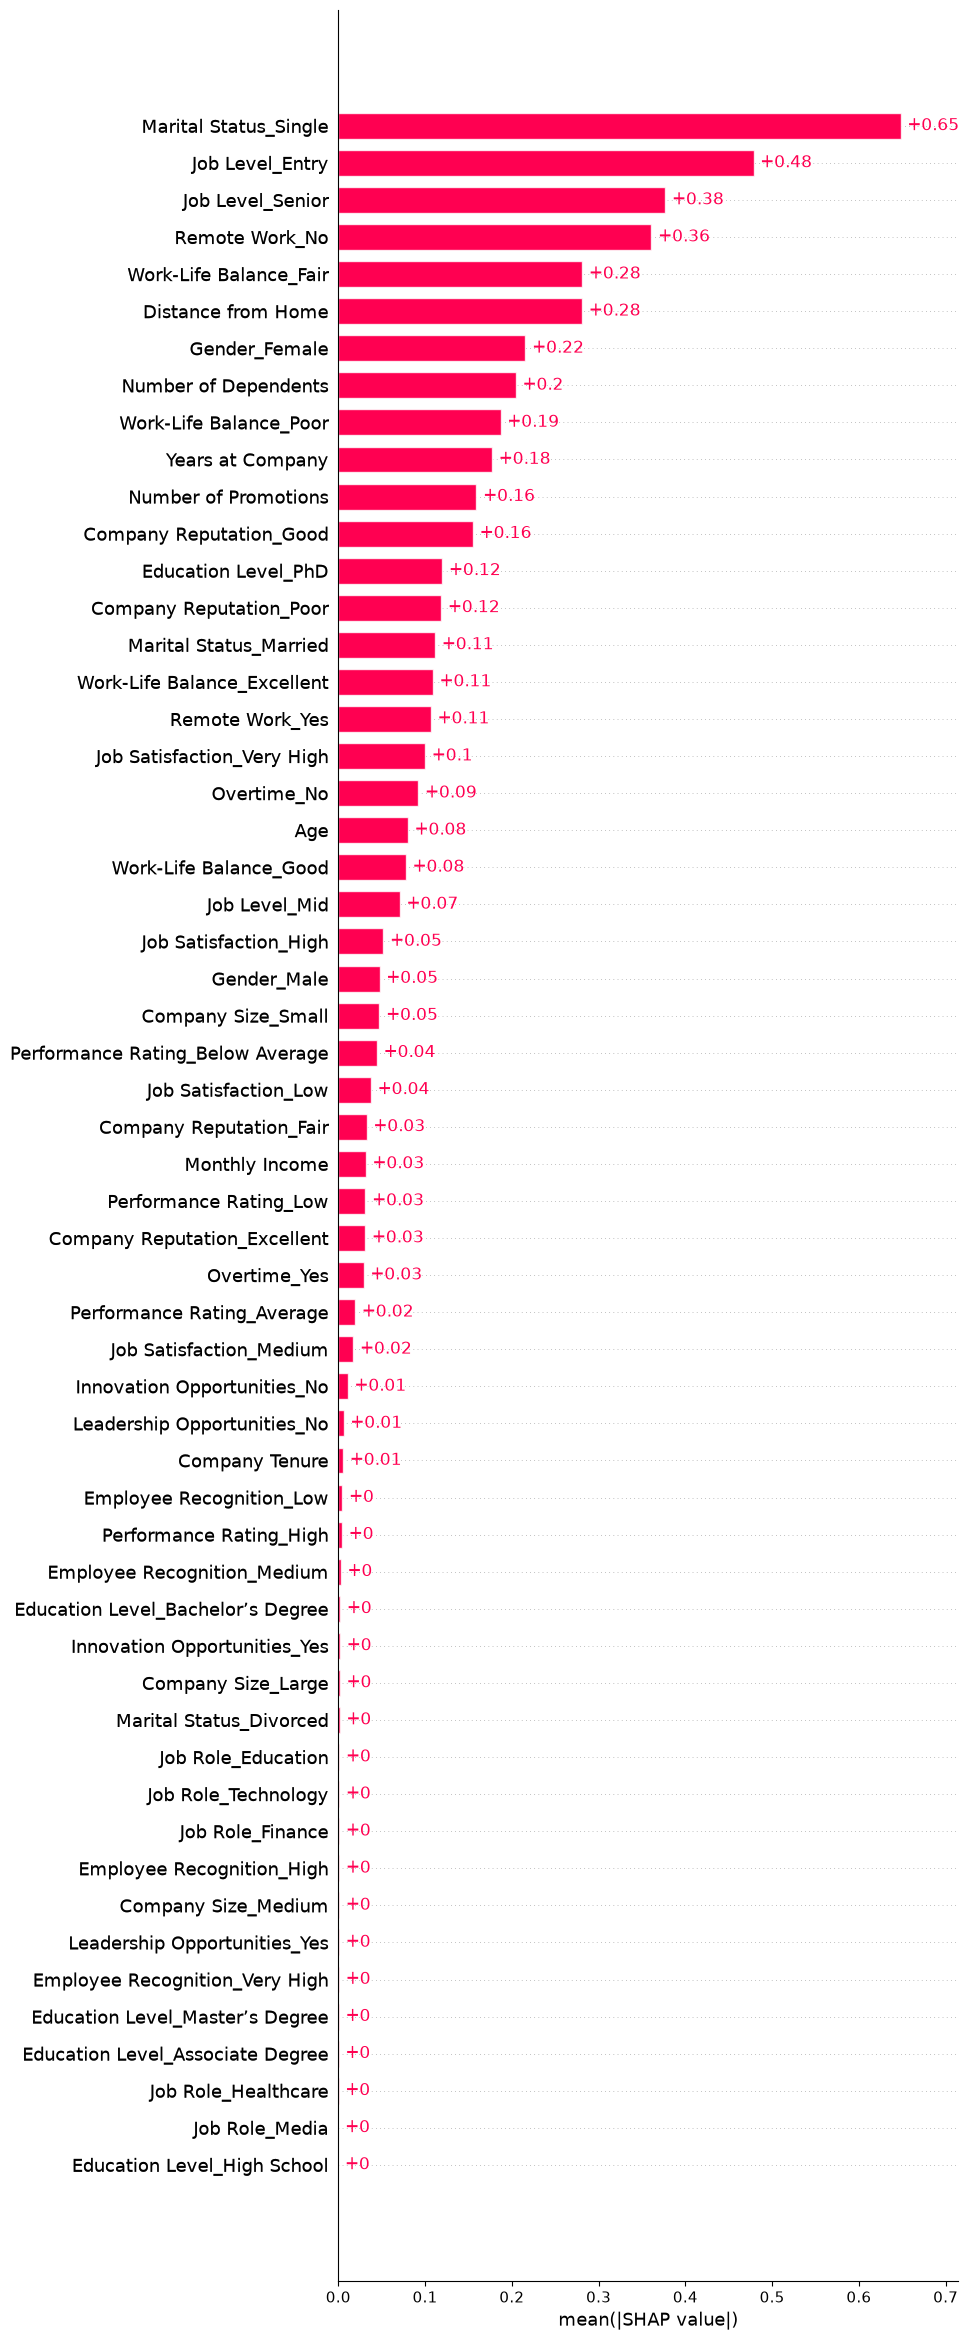

In [57]:
shap.plots.bar(shap_values,max_display=len(feature_names))

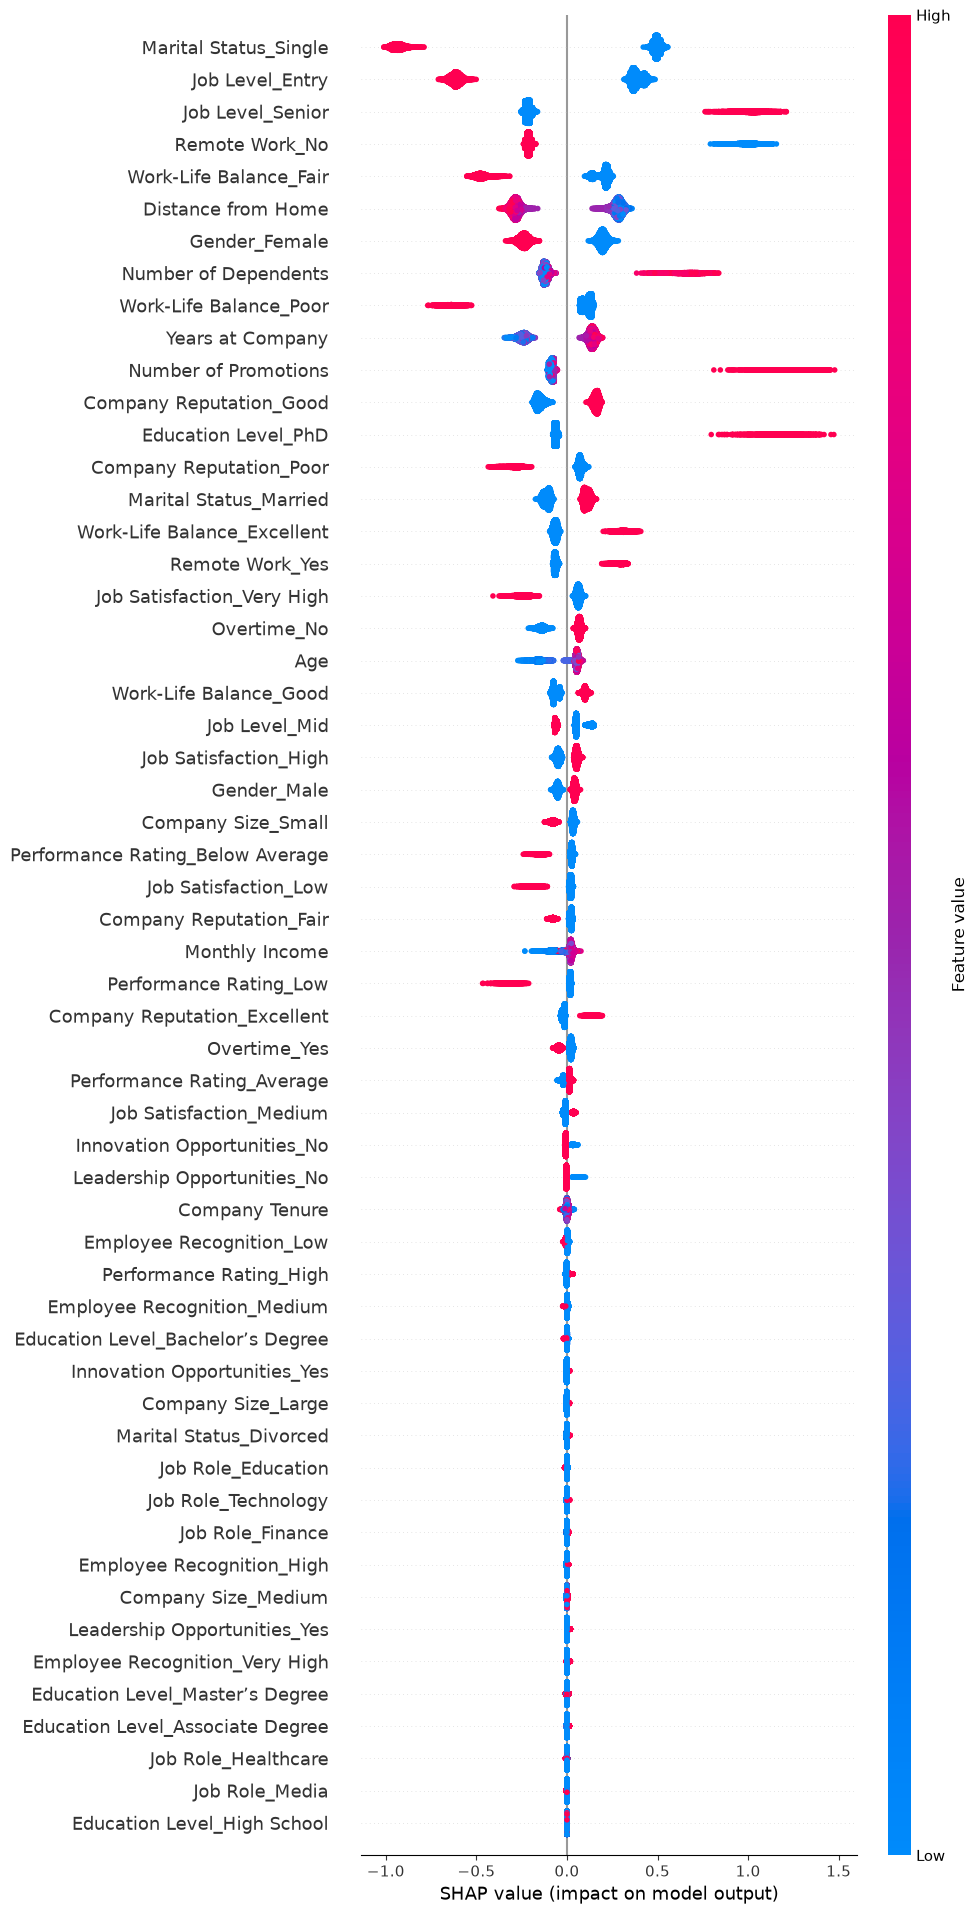

In [58]:
shap.plots.beeswarm(shap_values,max_display=len(feature_names))

Mlflow

In [60]:
import mlflow

In [64]:
mlflow.set_experiment("Attrition_classification")
with mlflow.start_run(run_name="XGBC_21-06-2026"):
    mlflow.log_params(params)

    mlflow.log_metric("Train accuracy",train_acc)
    mlflow.log_metric("Test accuracy",test_acc)

    mlflow.log_metric("Train f1_score",f1_score(y_train,y_train_pred))
    mlflow.log_metric("Test f1_score",f1_score(y_test,y_test_pred))

    mlflow.log_metric("Train precision",precision_score(y_train,y_train_pred))
    mlflow.log_metric("Test precision",precision_score(y_test,y_test_pred))

    mlflow.log_metric("Train recall",recall_score(y_train,y_train_pred))
    mlflow.log_metric("Test recall",recall_score(y_test,y_test_pred))

    mlflow.sklearn.log_model(final_pipeline,"final_pipeline",serialization_format="cloudpickle")


2026/06/21 13:44:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 13:44:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/21 13:44:52 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Admin\AppData\Local\Temp\tmp3icu_axa\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


In [70]:
best_run_id = "c3e2a7fabcd04f389d03cb4e5d8218ce"
best_run = f"runs:/{best_run_id}/final_pipeline"

In [71]:
result = mlflow.register_model(
    model_uri=best_run,
    name="attrition_classifier_registry"
)

Registered model 'attrition_classifier_registry' already exists. Creating a new version of this model...
2026/06/21 13:50:15 WARNING mlflow.tracking._model_registry.fluent: Run with id c3e2a7fabcd04f389d03cb4e5d8218ce has no artifacts at artifact path 'final_pipeline', registering model based on models:/m-62e3b42431084a05ab9b294ab2d62f51 instead


Created version '1' of model 'attrition_classifier_registry'.


In [74]:
production_model = mlflow.sklearn.load_model("models:/attrition_classifier_registry@production")
mlflow.sklearn.save_model(production_model,"production_model",serialization_format="cloudpickle")

2026/06/21 13:56:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/06/21 13:56:36 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: production_model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
